# Tree-Based Models: Random Forest, XGBoost, LightGBM

Train and tune tree-based models for GHR and DLI prediction.  
These models use one-hot encoded features (no scaling needed).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time
import json
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "../../datasets/processed"
MODEL_DIR = "../../models"
os.makedirs(MODEL_DIR, exist_ok=True)

X_train = pd.read_csv(f"{DATA_DIR}/X_train_tree.csv")
X_test = pd.read_csv(f"{DATA_DIR}/X_test_tree.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv")
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv")

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"Features: {list(X_train.columns)}")

X_train: (70080, 25), X_test: (17520, 25)
y_train: (70080, 2), y_test: (17520, 2)
Features: ['Day_of_Year', 'Tree_Width_m', 'Tree_Present', 'Window_Transmittance', 'WWR', 'Day_sin', 'Day_cos', 'Season_sin', 'Season_cos', 'Bld_Architecture', 'Bld_CEB', 'Bld_Housing', 'Ori_E', 'Ori_N', 'Ori_NE', 'Ori_NW', 'Ori_S', 'Ori_SE', 'Ori_W', 'Lvl_G', 'Lvl_M', 'Lvl_U', 'Effective_Transmittance', 'WWR_x_Transmittance', 'Tree_Effect']


In [2]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a multi-output model and return metrics dict."""
    y_pred = model.predict(X_test)
    if isinstance(y_pred, pd.DataFrame):
        y_pred = y_pred.values
    
    results = {}
    for i, target in enumerate(["GHR", "DLI"]):
        yt = y_test.iloc[:, i].values
        yp = y_pred[:, i] if y_pred.ndim > 1 else y_pred
        
        rmse = np.sqrt(mean_squared_error(yt, yp))
        mae = mean_absolute_error(yt, yp)
        r2 = r2_score(yt, yp)
        mape = np.mean(np.abs((yt - yp) / (yt + 1e-8))) * 100
        
        results[target] = {"RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}
        print(f"  {target}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.6f}, MAPE={mape:.2f}%")
    
    return results

all_results = {}

## 1. Random Forest

In [3]:
print("Training Random Forest...")
t0 = time.time()

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
train_time_rf = time.time() - t0
print(f"Training time: {train_time_rf:.1f}s")

# Inference speed test
t0 = time.time()
for _ in range(10):
    rf.predict(X_test.iloc[:1])
inference_ms_rf = (time.time() - t0) / 10 * 1000
print(f"Single inference: {inference_ms_rf:.2f}ms")

print("\nTest metrics:")
all_results["RandomForest"] = evaluate_model(rf, X_test, y_test, "RandomForest")
all_results["RandomForest"]["train_time"] = train_time_rf
all_results["RandomForest"]["inference_ms"] = inference_ms_rf

joblib.dump(rf, f"{MODEL_DIR}/random_forest.pkl")
print(f"\nSaved to {MODEL_DIR}/random_forest.pkl")

Training Random Forest...


Training time: 1.4s
Single inference: 16.41ms

Test metrics:


  GHR: RMSE=232.7505, MAE=112.1630, R²=0.944959, MAPE=18.62%
  DLI: RMSE=1.6908, MAE=0.8148, R²=0.944959, MAPE=18.62%



Saved to ../../models/random_forest.pkl


## 2. XGBoost

In [4]:
print("Training XGBoost...")
t0 = time.time()

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    tree_method="hist"
)

# XGBoost supports multi-output natively
xgb_multi = MultiOutputRegressor(xgb_model)
xgb_multi.fit(X_train, y_train)
train_time_xgb = time.time() - t0
print(f"Training time: {train_time_xgb:.1f}s")

t0 = time.time()
for _ in range(10):
    xgb_multi.predict(X_test.iloc[:1])
inference_ms_xgb = (time.time() - t0) / 10 * 1000
print(f"Single inference: {inference_ms_xgb:.2f}ms")

print("\nTest metrics:")
all_results["XGBoost"] = evaluate_model(xgb_multi, X_test, y_test, "XGBoost")
all_results["XGBoost"]["train_time"] = train_time_xgb
all_results["XGBoost"]["inference_ms"] = inference_ms_xgb

joblib.dump(xgb_multi, f"{MODEL_DIR}/xgboost.pkl")
print(f"\nSaved to {MODEL_DIR}/xgboost.pkl")

Training XGBoost...


Training time: 2.2s
Single inference: 3.51ms

Test metrics:
  GHR: RMSE=82.6144, MAE=49.8768, R²=0.993066, MAPE=12.67%
  DLI: RMSE=0.6038, MAE=0.3660, R²=0.992981, MAPE=12.78%

Saved to ../../models/xgboost.pkl


## 3. LightGBM

In [5]:
print("Training LightGBM...")
t0 = time.time()

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

lgb_multi = MultiOutputRegressor(lgb_model)
lgb_multi.fit(X_train, y_train)
train_time_lgb = time.time() - t0
print(f"Training time: {train_time_lgb:.1f}s")

t0 = time.time()
for _ in range(10):
    lgb_multi.predict(X_test.iloc[:1])
inference_ms_lgb = (time.time() - t0) / 10 * 1000
print(f"Single inference: {inference_ms_lgb:.2f}ms")

print("\nTest metrics:")
all_results["LightGBM"] = evaluate_model(lgb_multi, X_test, y_test, "LightGBM")
all_results["LightGBM"]["train_time"] = train_time_lgb
all_results["LightGBM"]["inference_ms"] = inference_ms_lgb

joblib.dump(lgb_multi, f"{MODEL_DIR}/lightgbm.pkl")
print(f"\nSaved to {MODEL_DIR}/lightgbm.pkl")

Training LightGBM...


Training time: 3.1s
Single inference: 0.88ms

Test metrics:
  GHR: RMSE=165.1271, MAE=100.2085, R²=0.972296, MAPE=24.10%
  DLI: RMSE=1.2020, MAE=0.7292, R²=0.972182, MAPE=24.15%

Saved to ../../models/lightgbm.pkl


## 4. Feature Importance (Best Tree Model)

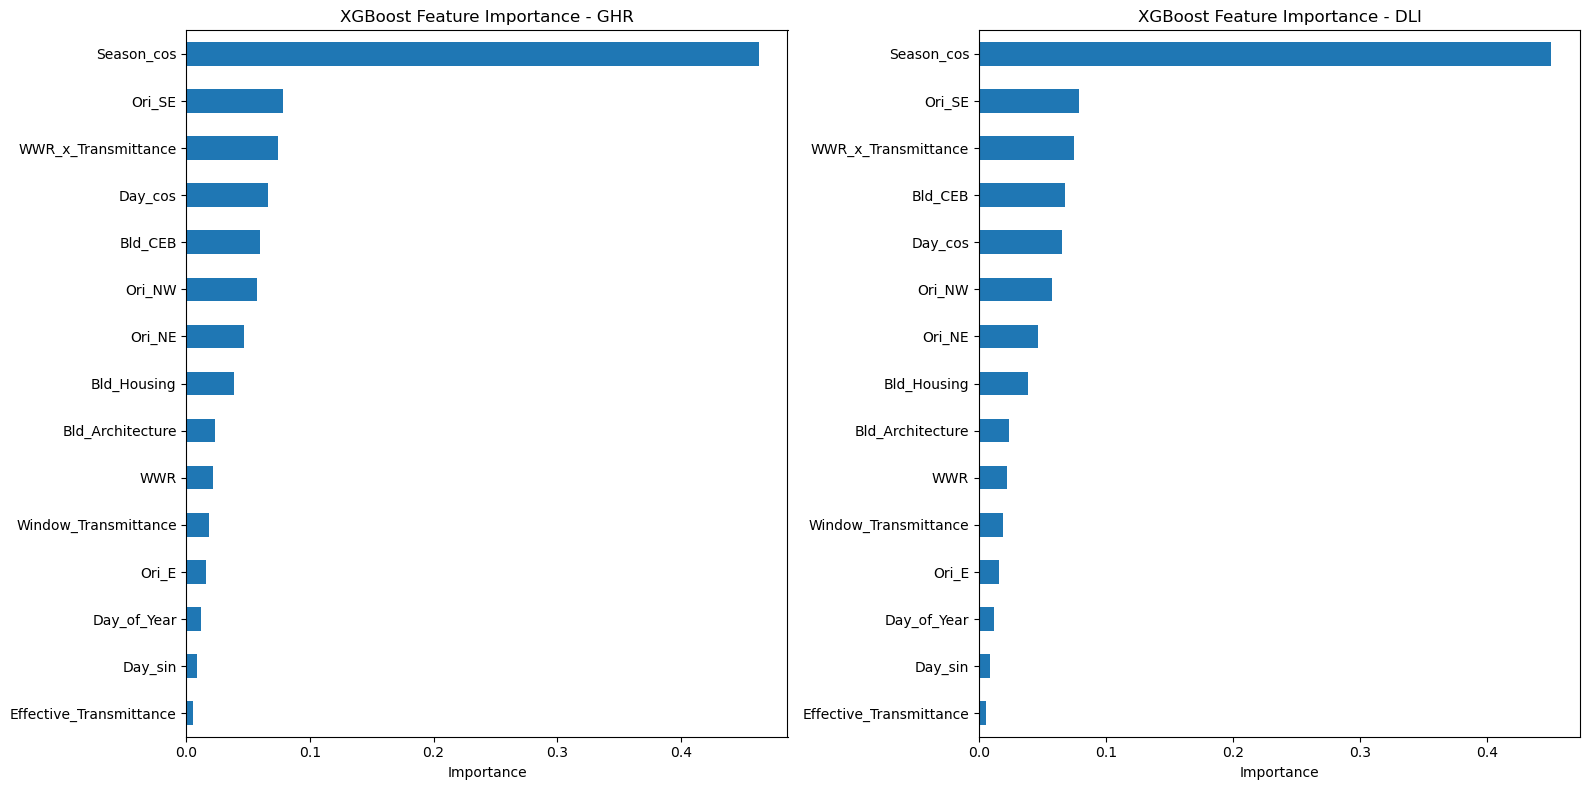

In [6]:
# Feature importance from XGBoost (GHR and DLI separately)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, (target, ax) in enumerate(zip(["GHR", "DLI"], axes)):
    importances = xgb_multi.estimators_[idx].feature_importances_
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)
    feat_imp.tail(15).plot(kind="barh", ax=ax)
    ax.set_title(f"XGBoost Feature Importance - {target}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 5. Tree Models Summary

In [7]:
# Summary table
rows = []
for name, res in all_results.items():
    for target in ["GHR", "DLI"]:
        rows.append({
            "Model": name,
            "Target": target,
            "RMSE": res[target]["RMSE"],
            "MAE": res[target]["MAE"],
            "R²": res[target]["R2"],
            "MAPE(%)": res[target]["MAPE"],
            "Train(s)": res["train_time"],
            "Inference(ms)": res["inference_ms"]
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

# Save results for comparison notebook
with open(f"{MODEL_DIR}/tree_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nResults saved to {MODEL_DIR}/tree_results.json")

       Model Target       RMSE        MAE       R²   MAPE(%)  Train(s)  Inference(ms)
RandomForest    GHR 232.750502 112.163007 0.944959 18.621103  1.364423      16.407275
RandomForest    DLI   1.690839   0.814819 0.944959 18.621103  1.364423      16.407275
     XGBoost    GHR  82.614350  49.876785 0.993066 12.674074  2.215475       3.514314
     XGBoost    DLI   0.603808   0.366017 0.992981 12.779813  2.215475       3.514314
    LightGBM    GHR 165.127114 100.208495 0.972296 24.096703  3.128751       0.883985
    LightGBM    DLI   1.202042   0.729157 0.972182 24.154942  3.128751       0.883985

Results saved to ../../models/tree_results.json
